Task D

In [1]:
from numba import njit, prange
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.special import erfc

N = 200
dx = 1.0 / N
D = 1.0

@njit(parallel=True)
def step(c, c_next, alpha):
    for i in prange(N):
        ip = 0 if i == N - 1 else i + 1
        im = N - 1 if i == 0 else i - 1
        for j in range(1, N):
            c_next[i, j] = c[i, j] + alpha * (
                c[ip, j] + c[im, j] + c[i, j + 1] + c[i, j - 1] - 4.0 * c[i, j]
            )

    # Dirichlet in y
    for i in range(N):
        c_next[i, 0] = 0.0
        c_next[i, N] = 1.0


Task E

In [2]:
def analytic_c_y(y, t, D=1.0, n_terms=200):
    y = np.asarray(y, dtype=np.float64)

    if t <= 0:
        return np.zeros_like(y)

    s = 2.0 * np.sqrt(D * t)
    out = np.zeros_like(y)

    for i in range(n_terms):
        a = (1.0 - y + 2.0 * i) / s
        b = (1.0 + y + 2.0 * i) / s
        out += erfc(a) - erfc(b)

    return out


def sim_diffusion_save_times(dt, t_end, save_times, tol):
    """
    Runs explicit 2D diffusion and saves c(x,y,t) ONLY at the requested save_times.

    If tol is not None, stops early when max|c_next - c| < tol (checked every 50 steps).
    If tol is None, always runs until t_end.

    Returns: c_final, saved_t (array), saved_frames (list)
    """
    alpha = D * dt / (dx * dx)
    if alpha > 0.25:
        raise ValueError(f"alpha={alpha:.6f} > 0.25, reduce dt or increase N")

    save_times = np.array(sorted(set(float(t) for t in save_times)), dtype=np.float64)
    if save_times[0] < 0.0 or save_times[-1] > t_end:
        raise ValueError("All save_times must satisfy 0 <= t <= t_end")

    steps = int(np.ceil(t_end / dt))

    c = np.zeros((N, N + 1), dtype=np.float64)
    c_next = np.zeros_like(c)

    # initial + boundary conditions
    c[:, 0] = 0.0
    c[:, N] = 1.0

    saved = []
    saved_t = []

    k = 0
    t = 0.0

    # Save at t=0 if requested
    if np.isclose(save_times[0], 0.0):
        saved.append(c.copy())
        saved_t.append(t)
        k = 1

    for n in range(1, steps + 1):
        step(c, c_next, alpha)
        t = n * dt

        # Equilibrium check (only if tol is provided)
        if tol is not None and (n % 50) == 0:
            err = float(np.max(np.abs(c_next - c)))  
            if err < tol:
                # accept step, save any remaining requested snapshots we reached, then stop
                c, c_next = c_next, c

                while k < len(save_times) and t >= save_times[k] - 0.5 * dt:
                    saved.append(c.copy())
                    saved_t.append(t)
                    k += 1

                return c, np.array(saved_t), saved

        c, c_next = c_next, c

        # Save when reaching or crossing requested times
        while k < len(save_times) and t >= save_times[k] - 0.5 * dt:
            saved.append(c.copy())
            saved_t.append(t)
            k += 1

        # If we've saved everything and reached t_end, we can stop
        if k >= len(save_times) and t >= t_end - 0.5 * dt:
            break

    return c, np.array(saved_t), saved


Task F

/tmp/ipykernel_30045/2651380441.py:124: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


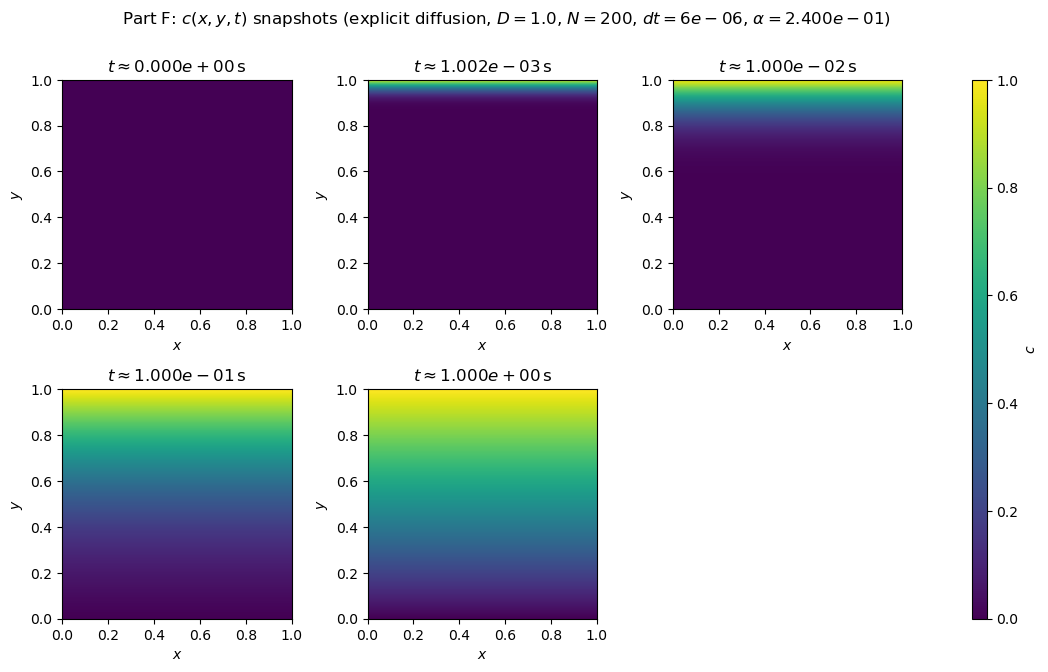

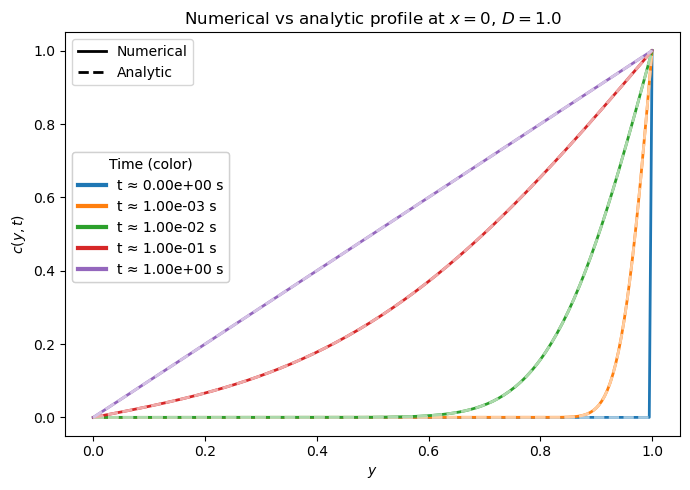

In [3]:
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb


def plot_heatmap(ax, c, title="", extent=(0.0, 1.0, 0.0, 1.0), vmin=None, vmax=None):
    im = ax.imshow(
        c.T,
        origin="lower",
        extent=extent,
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
    )
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")
    ax.set_title(title)
    return im

def compare_profiles(saved, saved_t, D=1.0, times_to_plot=(0, 0.001, 0.01, 0.1, 1.0), n_terms=200):

    def lighten(color, amount=0.35):
        r, g, b = to_rgb(color)
        return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

    saved_t = np.asarray(saved_t, dtype=np.float64)
    Ny = saved[0].shape[1]
    y = np.linspace(0.0, 1.0, Ny)

    fig, ax = plt.subplots(figsize=(7, 5))

    time_handles = []
    time_labels = []

    for t_req in times_to_plot:
        k = int(np.argmin(np.abs(saved_t - float(t_req))))
        t = float(saved_t[k])

        c_num = saved[k][0, :]
        c_ana = analytic_c_y(y, t, D=D, n_terms=n_terms)

        (ln_num,) = ax.plot(y, c_num, linewidth=2, zorder=2)

        ax.plot(
            y, c_ana, "--",
            color=lighten(ln_num.get_color(), amount=0.6),
            linewidth=2,
            zorder=3,
        )

        time_handles.append(Line2D([0], [0], color=ln_num.get_color(), lw=3))
        time_labels.append(f"t ≈ {t:.2e} s")

    # Legend 1: line styles (Numerical vs Analytic) 
    style_handles = [
        Line2D([0], [0], color="k", lw=2, linestyle="-", label="Numerical"),
        Line2D([0], [0], color="k", lw=2, linestyle="--", label="Analytic"),
    ]
    leg1 = ax.legend(handles=style_handles, loc="upper left", frameon=True)

    # Legend 2: colors map to time, placed under legend 1 
    leg2 = ax.legend(
        handles=time_handles,
        labels=time_labels,
        title="Time (color)",
        loc="upper left",
        bbox_to_anchor=(0.0, 0.72), 
        frameon=True,
    )

    ax.add_artist(leg1)
    ax.add_artist(leg2)

    ax.set_xlabel(r"$y$")
    ax.set_ylabel(r"$c(y,t)$")
    ax.set_title(rf"Numerical vs analytic profile at $x=0$, $D={D}$")
    fig.tight_layout()
    plt.show()

dt = 6e-6
t_end = 1.0
alpha = D * dt / (dx * dx)

times_F = (0, 0.001, 0.01, 0.1, 1.0)

c_final, t_F, frames_F = sim_diffusion_save_times(dt, t_end, times_F, tol=None)

vmin_F = min(float(np.min(f)) for f in frames_F)
vmax_F = max(float(np.max(f)) for f in frames_F)

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.06], wspace=0.35, hspace=0.35)

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[1, 2]),
]
cax = fig.add_subplot(gs[:, 3])

ims = []
for k, (c_frame, t_frame) in enumerate(zip(frames_F, t_F)):
    ims.append(
        plot_heatmap(
            axes[k],
            c_frame,
            title=rf"$t \approx {t_frame:.3e}\,\mathrm{{s}}$",
            extent=(0.0, 1.0, 0.0, 1.0),
            vmin=vmin_F,
            vmax=vmax_F,
        )
    )

for k in range(len(frames_F), len(axes)):
    axes[k].axis("off")

fig.colorbar(ims[0], cax=cax, label=r"$c$")
fig.suptitle(
    rf"Part F: $c(x,y,t)$ snapshots (explicit diffusion, $D={D}$, $N={N}$, $dt={dt}$, $\alpha={alpha:.3e}$)",
    y=0.98
)
fig.tight_layout()
plt.show()

compare_profiles(frames_F, t_F, D=D, times_to_plot=times_F, n_terms=200)


Task G

In [5]:
from IPython.display import HTML

n_frames = 200
times_G = np.linspace(0.0, t_end, n_frames)

_, t_G, frames_G = sim_diffusion_save_times(dt, t_end, times_G, tol=1e-6)

vmin_G = min(float(np.min(f)) for f in frames_G)
vmax_G = max(float(np.max(f)) for f in frames_G)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(
    frames_G[0].T,
    origin="lower",
    extent=(0.0, 1.0, 0.0, 1.0),
    vmin=vmin_G,
    vmax=vmax_G,
    aspect="equal",
)
plt.colorbar(im, ax=ax, label=r"$c$")
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$y$")

base_title = rf"2D diffusion (explicit), $D={D}$, $N={N}$, $dt={dt}$, $\alpha={alpha:.3e}$"
title = ax.set_title(base_title + "\n" + rf"$t = {t_G[0]:.3e}\,\mathrm{{s}}$")

def update(frame_idx):
    im.set_data(frames_G[frame_idx].T)
    title.set_text(base_title + "\n" + rf"$t = {t_G[frame_idx]:.3e}\,\mathrm{{s}}$")
    return im, title

ani = FuncAnimation(fig, update, frames=len(frames_G), interval=40, blit=False)
plt.close(fig)
HTML(ani.to_jshtml())
